In [2]:
import os
from dotenv import load_dotenv
from huggingface_hub import login
from datasets import load_dataset
import matplotlib.pyplot as plt
from tqdm.notebook import tqdm
import numpy as np
import random
# from pricer.items import Item
# from pricer.parser import parse
load_dotenv(override=True)

True

In [3]:
hf_token = os.environ['HF_TOKEN']

login(hf_token, add_to_git_credential=True)

Note: Environment variable`HF_TOKEN` is set and is the current active token independently from the token you've just configured.


# Load dataset from Huggingface

In [10]:
data_set = load_dataset("Shopify/product-catalogue")



In [20]:
train_ds = data_set['train']
test_ds = data_set['test']

print(f"Number of training examples: {len(train_ds)}")
print(f"Number of test examples: {len(test_ds)}")


Number of training examples: 38631
Number of test examples: 9658


## Example of an data point

Full data point example:
{'product_title': 'Airplane Piggy Bank', 'product_description': 'The sweetest gift!', 'product_image': <PIL.JpegImagePlugin.JpegImageFile image mode=RGB size=785x734 at 0x124AFD7C0>, 'potential_product_categories': ['Toys & Games > Toys > Flying Toys', 'Home & Garden > Decor > Piggy Banks & Money Jars', 'Toys & Games > Toys > Flying Toys > Model Aircrafts', 'Arts & Entertainment > Hobbies & Creative Arts > Arts & Crafts > Art & Crafting Materials > Pottery & Sculpting Materials > Clay & Modeling Dough > Clay > Sculpting Clay', 'Toys & Games > Toys > Beach & Sand Toys > Sand Castle Molds', 'Hardware > Tools > Dollies & Hand Trucks', 'Home & Garden > Decor > Piggy Banks & Money Jars > Piggy Banks', 'Toys & Games > Toys > Play Vehicles > Toy Airplanes'], 'ground_truth_brand': 'Child to Cherish', 'ground_truth_is_secondhand': False, 'ground_truth_category': 'Home & Garden > Decor > Piggy Banks & Money Jars > Piggy Banks'}
Ground truth category: Home & Garden > Kitc

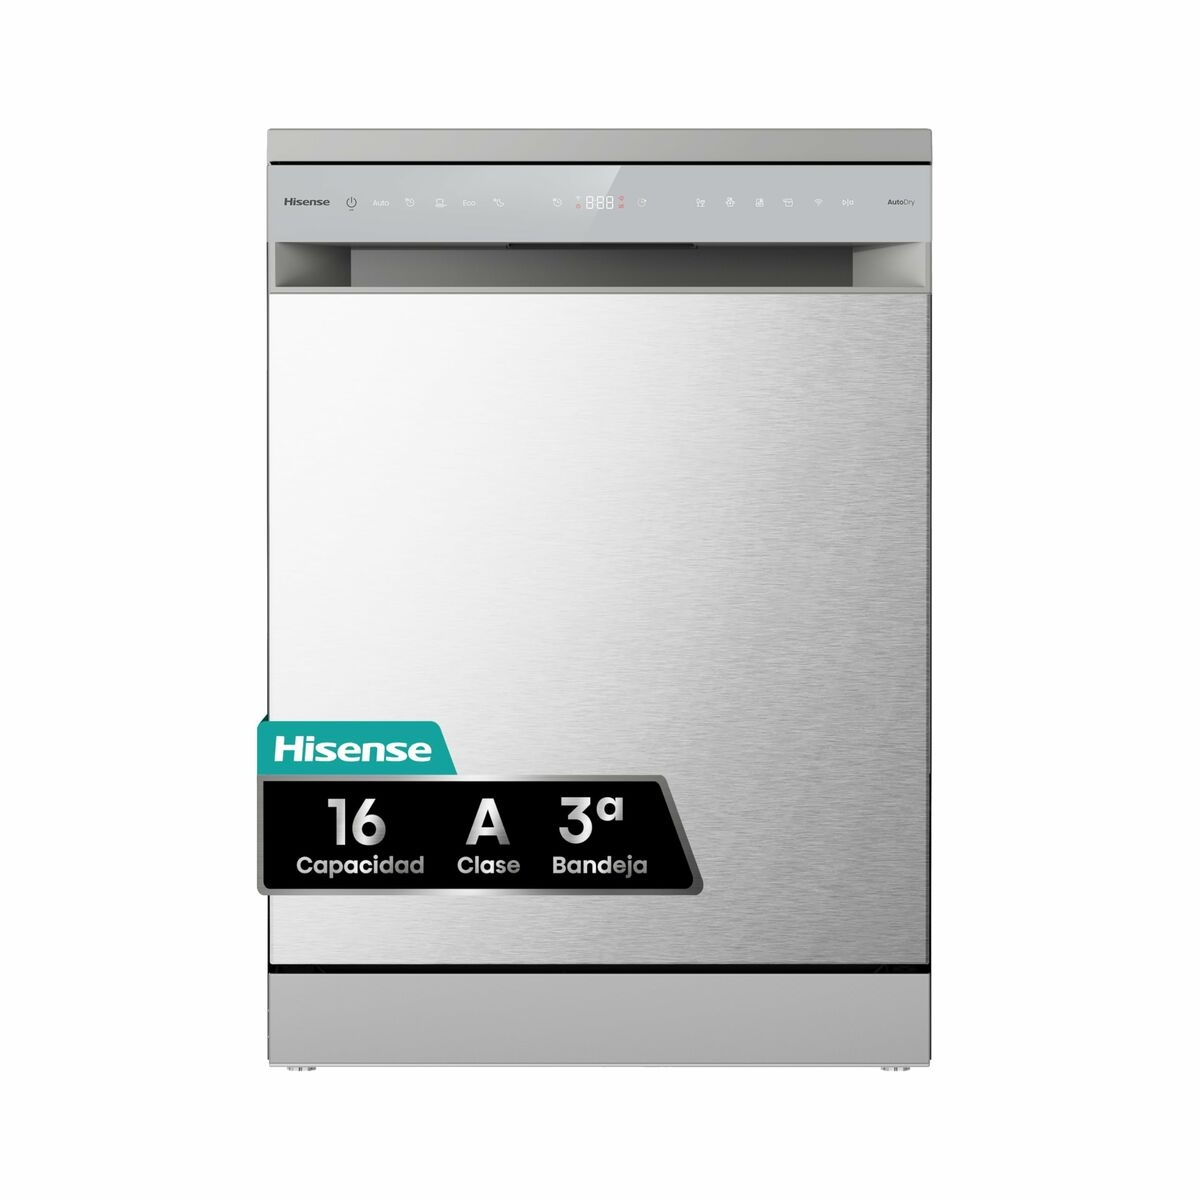

In [33]:
print("Full data point example:")
print(train_ds[0])
print("Ground truth category:", test_ds[0]["ground_truth_category"])
img = test_ds[0]["product_image"]
display(img)

## Collect the top level categories from training data

One can run the following block of code for the first time to automatically collect the cateogories. Alternatively, if the list of categories readily available, skip to the next block of code.

In [ ]:
#extract top level category from the ground truth category
def top_level_category_extractor(example):
    top_lev = example['ground_truth_category'].split(' > ')[0]
    return top_lev

top_level_list = set([top_level_category_extractor(example) for example in train_ds])

In [ ]:


top_level_list = {'Bundles', 'Food, Beverages & Tobacco', 'Product Add-Ons', 'Gift Cards', 'Hardware', 'Home & Garden', 'Sporting Goods', 'Electronics', 'Baby & Toddler', 'Uncategorized', 'Apparel & Accessories', 'Furniture', 'Media', 'Toys & Games', 'Religious & Ceremonial', 'Luggage & Bags', 'Cameras & Optics', 'Arts & Entertainment', 'Software', 'Office Supplies', 'Animals & Pet Supplies', 'Vehicles & Parts', 'Health & Beauty', 'Business & Industrial', 'Services'}


Top level categories in the dataset:
{'Bundles', 'Food, Beverages & Tobacco', 'Product Add-Ons', 'Toys & Games', 'Religious & Ceremonial', 'Gift Cards', 'Hardware', 'Home & Garden', 'Luggage & Bags', 'Sporting Goods', 'Cameras & Optics', 'Electronics', 'Arts & Entertainment', 'Software', 'Office Supplies', 'Animals & Pet Supplies', 'Baby & Toddler', 'Uncategorized', 'Apparel & Accessories', 'Furniture', 'Vehicles & Parts', 'Media', 'Health & Beauty', 'Business & Industrial', 'Services'}
<class 'set'>


Top level categories in the dataset:
{'Bundles', 'Food, Beverages & Tobacco', 'Product Add-Ons', 'Toys & Games', 'Religious & Ceremonial', 'Gift Cards', 'Hardware', 'Home & Garden', 'Luggage & Bags', 'Sporting Goods', 'Cameras & Optics', 'Electronics', 'Arts & Entertainment', 'Software', 'Office Supplies', 'Animals & Pet Supplies', 'Baby & Toddler', 'Uncategorized', 'Apparel & Accessories', 'Furniture', 'Vehicles & Parts', 'Media', 'Health & Beauty', 'Business & Industrial', 'Services'}
